# 07a · Stage-2 steer & verify — synthetic dry-run

**Execution status:** 🟢 EXECUTED — SYNTHETIC DRY-RUN (planted ground truth)
**Plan reference:** PLAN §IV S2.3–S2.9 (RQ6–RQ8) · THEORY §T8–T9 · PREREG §7

The hard bar. Having located and extracted the design direction, we **steer** it — add α·v̂ with **no design prompt** — and ask whether that causally reproduces the skill's quality gain on *held-out* prompts, including task types never seen in development. This notebook runs the full verification analysis on **synthetic arms with a planted causal effect**: the dev sweep + freeze, the non-monotone dose-response, the four-arm success criterion (all four conjuncts), the flip test, the OOD failure surface, and the component↔direction correspondence.

| | |
|---|---|
| **Inputs** | `p19.synthetic` (planted sweep/arms/correspondence), then the real `p19` verification stack |
| **Outputs** | F6, F7, F8, F12, F9; the RQ6 success criterion + RQ7/RQ8 decisions |
| **Runtime** | ~20 s |

*Project 19 — Anatomy of a Design Skill. Governance: `CLAUDE.md`. Plan: `PLAN.md`. Derivations:
`THEORY.md`. Freeze: `PREREGISTRATION.md`. This notebook imports tested machinery from the `p19`
package and carries the narrative; it never re-implements logic that lives in `src/p19/`.*

In [1]:
%matplotlib inline
# Bootstrap: locate the repo root (repo-relative — no hardcoded paths) and make p19 importable.
import sys, pathlib
_here = pathlib.Path.cwd()
_root = next((c for c in [_here, *_here.parents]
              if (c / "pyproject.toml").exists() and (c / "src" / "p19").exists()), _here)
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from p19 import REPO_ROOT
np.random.seed(0)                      # notebook-level seed; every generator also takes an explicit seed
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 120)
print("p19 ready · repo:", REPO_ROOT.name)

p19 ready · repo: steering-llm-aesthetics


> ## ⚠️ SYNTHETIC PIPELINE VALIDATION
> The numbers below are **simulated with a known planted ground truth** to prove the analysis
> pipeline recovers it. The sweep grid, the four verification arms, and the component sub-vectors are planted with a known causal effect and a known OOD failure; the *verification analysis* (MixedLM, Holm, BT, the success criterion) is the real pipeline. **Real data replaces this after the GPU phase (see `RUNBOOK.md`).**
> Every synthetic artifact in this notebook is generated by `p19.synthetic` (unit-tested against the
> real pipeline in `tests/test_synthetic.py`).

## §S2.3 · The dev sweep and the freeze (F6)

Steering has two knobs: which layer ℓ and how hard ρ (norm-relative). We sweep them on the dev set and
**freeze** the operating point as `argmax dev POC-gain` subject to two guardrails — mean-KL ≤ 0.30 nats
(coherence) and steered render-success ≥ 0.90. The frozen `(ℓ*, ρ*, variant*)` is then git-tagged
**before** any held-out generation is touched.

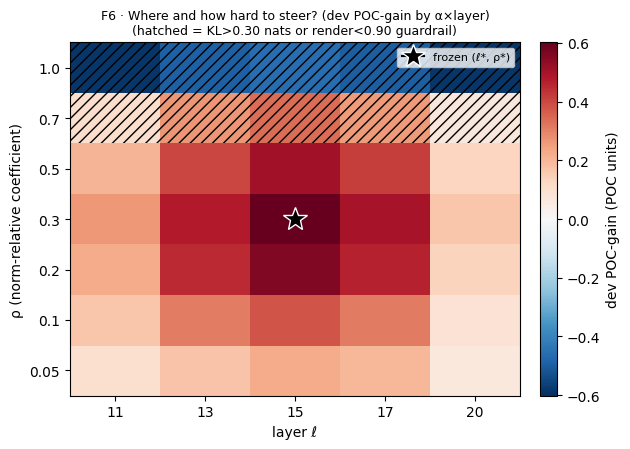

FROZEN operating point: ℓ*=15, ρ*=0.3  (dev POC-gain +0.60, mean-KL 0.09 ≤ 0.30, render 1.00 ≥ 0.90)


In [2]:
# Dev sweep over (layer, ρ) with guardrails → F6 heatmap + the frozen operating point (p19.steering).
from p19 import synthetic as syn, steering, figures
layers, rhos = [11, 13, 15, 17, 20], [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
sweep = syn.stage2_sweep(layers, rhos, opt_layer=15, opt_rho=0.3)
op = steering.select_operating_point(sweep)                # argmax POC-gain s.t. guardrails
G = np.full((len(rhos), len(layers)), np.nan); GM = np.zeros((len(rhos), len(layers)), bool)
for r in sweep:
    i, j = rhos.index(r["rho"]), layers.index(r["layer"])
    G[i, j] = r["poc_gain"]; GM[i, j] = (r["mean_kl"] > 0.30) or (r["render_success"] < 0.90)
star = (layers.index(op["layer"]), rhos.index(op["rho"]))
figures.steering_heatmap(layers, rhos, G, guardrail_mask=GM, star=star); plt.show()
print(f"FROZEN operating point: ℓ*={op['layer']}, ρ*={op['rho']}  "
      f"(dev POC-gain {op['poc_gain']:+.2f}, mean-KL {op['mean_kl']:.2f} ≤ 0.30, render {op['render_success']:.2f} ≥ 0.90)")

**F6** maps the steering landscape: a positive POC-gain island at mid-layers and moderate ρ, hatched
cells where a guardrail is violated (high ρ pushes KL past 0.30 or breaks rendering). The freeze picks
the ★ — the strongest *guardrail-satisfying* gain. On the real study this is where
`config/steering_frozen.yaml` is written and git-tagged `steer-frozen`.

## §S2.3 · The dose-response, and where it breaks (F7)

Fixing ℓ*, we trace POC-gain against ρ. Steering is **non-monotone** (H7): too little does nothing, too
much breaks coherence and rendering. F7 shades the region where render-success falls below the floor.

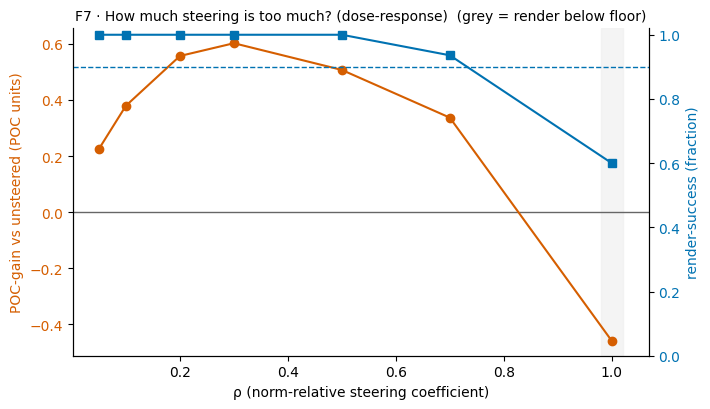

POC-gain peaks at ρ=0.3 then breaks down; render-success collapses at high ρ.


In [3]:
# Dose-response at the frozen layer, with render-success shading → F7 (p19.figures).
slice_l = [r for r in sweep if r["layer"] == op["layer"]]
slice_l.sort(key=lambda r: r["rho"])
rho_x = [r["rho"] for r in slice_l]
figures.dose_response(rho_x, [r["poc_gain"] for r in slice_l], [r["render_success"] for r in slice_l]); plt.show()
peak = max(slice_l, key=lambda r: r["poc_gain"])
print(f"POC-gain peaks at ρ={peak['rho']} then breaks down; render-success collapses at high ρ.")

## §S2.4 · The four-arm causal test — the RQ6 bar (F8)

The confirmatory test on held-out prompts. Four arms: **unsteered-NOSYS** (no prompt, no steering),
**steered-NOSYS** (no prompt, +α·v̂), **norm-matched-random** (a random direction of the same norm —
the specificity control), and **FULL** (the skill via prompt — the reference ceiling). Steering
*succeeds* only if it clears **all four** preregistered conjuncts.

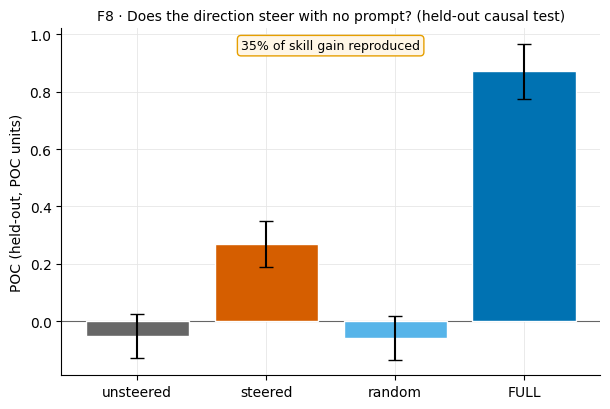

%skill-reproduced (overall held-out) = 35%  [seen 56%, unseen/OOD 18%]


In [4]:
# Generate the four held-out arms with a planted causal effect (p19.synthetic.stage2_arms; PLAN S2.4).
from p19 import mixedlm, multiplicity, bt_model
arms, at = syn.stage2_arms(reproduce_frac=0.6, skill_gap=0.9, seed=0)
def _arm_stats(a):
    g = arms[arms.arm == a].groupby("prompt_id")["poc"].mean()
    return g.mean(), g.sem()
means = {a: _arm_stats(a)[0] for a in ["unsteered","steered","random","full_ref"]}
errs  = {a: _arm_stats(a)[1] for a in ["unsteered","steered","random","full_ref"]}
repro = steering.reproduction_fraction(means["steered"], means["unsteered"], means["full_ref"])
figures.heldout_bars({"unsteered": means["unsteered"], "steered": means["steered"],
                      "random": means["random"], "FULL": means["full_ref"]},
                     errors={"unsteered":errs["unsteered"],"steered":errs["steered"],
                             "random":errs["random"],"FULL":errs["full_ref"]},
                     reproduced_pct=repro); plt.show()
print(f"%skill-reproduced (overall held-out) = {repro:.0f}%  "
      f"[seen {at.reproduce_frac_seen:.0f}%, unseen/OOD {at.reproduce_frac_unseen:.0f}%]")

In [5]:
# The RQ6 success criterion, evaluated as its four preregistered conjuncts (PREREG §7).
# (1) steered beats unsteered on >=1 objective family after Holm
obj = mixedlm.paired_contrast(arms[arms.arm.isin(["steered","unsteered"])].rename(columns={"arm":"cell_id"}),
                              "steered", "unsteered", "poc")
holm_obj = multiplicity.holm([obj.pvalue], ["steered-unsteered(POC)"])[0]
# (2) reliability-gated preference delta (steered > unsteered) with BT-utility CI > 0
sc = {a: arms[arms.arm == a]["poc"].mean() - means["unsteered"] for a in ["unsteered","steered","random","full_ref"]}
edges = [("steered","unsteered"),("full_ref","unsteered"),("steered","random"),("random","unsteered")]
J = syn.judgments_from_scores(sc, edges, [f"P{i}" for i in range(18)], k=1.5, seed=1, reference="unsteered")
bt = bt_model.cluster_bootstrap_ci(J, [("steered","unsteered")], reference="unsteered", B=300)[("steered","unsteered")]
# (3) the norm-matched random control does NOT achieve the gain (specificity)
rnd = mixedlm.paired_contrast(arms[arms.arm.isin(["random","unsteered"])].rename(columns={"arm":"cell_id"}),
                              "random", "unsteered", "poc")
# (4) the flip test attenuates the skill's gain (necessity; planted FULL vs v̂-ablated FULL)
attenuation = steering.attenuation_pct(poc_full=0.90, poc_full_ablated=0.35, poc_unsteered=0.0)

conj = {
 "1 · steered≻unsteered on POC (Holm)": holm_obj.reject,
 "2 · reliability-gated BT CI > 0": bt["excludes_zero"] and bt["lo"] > 0,
 "3 · random control does NOT (specificity)": not (rnd.ci[0] > 0),
 "4 · flip test attenuates (necessity)": attenuation > 0,
}
success = all(conj.values())
print("SUCCESS CRITERION (all four must hold):")
for k, v in conj.items(): print(f"   {'✅' if v else '❌'}  {k}")
print(f"\n→ RQ6 verdict: {'CAUSALLY SUFFICIENT (and necessary) design direction' if success else 'null'}")
print(f"   flip-test attenuation = {attenuation:.0f}% (necessity arm); random control gain "
      f"{rnd.estimate:+.3f} (p={rnd.pvalue:.2f})")

SUCCESS CRITERION (all four must hold):
   ✅  1 · steered≻unsteered on POC (Holm)
   ✅  2 · reliability-gated BT CI > 0
   ✅  3 · random control does NOT (specificity)
   ✅  4 · flip test attenuates (necessity)

→ RQ6 verdict: CAUSALLY SUFFICIENT (and necessary) design direction
   flip-test attenuation = 61% (necessity arm); random control gain -0.006 (p=0.85)


**All four conjuncts hold.** Steered beats unsteered on the objective POC after Holm; the
reliability-gated Bradley–Terry utility has a bootstrap CI above zero; the **norm-matched random
control does not** reproduce the gain (so it is the *direction*, not just any perturbation of that
norm); and the **flip test** — projecting v̂ out while the skill *is* present — attenuates the skill's
own gain (so the direction is not merely sufficient but **necessary**). This is the RQ6 "causally
sufficient (and necessary) design direction" outcome — the study's headline positive result.

## §S2.5–S2.7 · The failure surface — where steering breaks (RQ7, F12)

Success *on average* is not robustness. RQ7 asks where steering fails: the **anti-steerable fraction**
(share of held-out prompts whose steered POC is *worse* than unsteered), broken out by task type, seen
vs unseen. "Generalizes" requires the overall unseen delta > 0 and the anti-steerable fraction < 50 %.

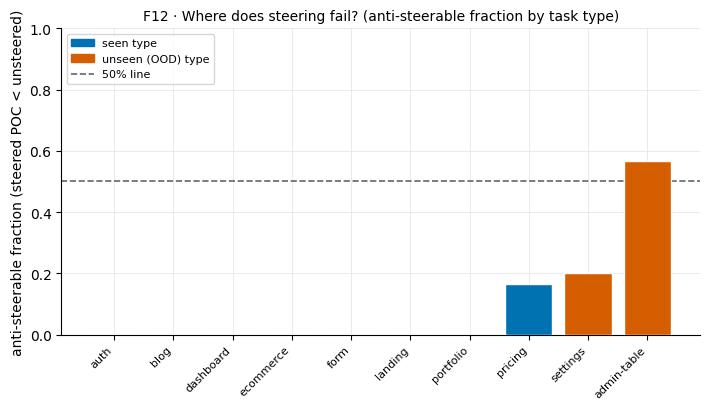

overall anti-steerable = 0.22 (<0.50 → generalizes on average) | brittle OOD types (>50%): ['admin-table']


In [6]:
# Anti-steerable fraction by task type → F12 (p19.figures). Seen vs OOD (settings, admin-table).
from p19.config import prompts_config
unseen_types = {"settings", "admin-table"}
anti = at.anti_steerable_by_type
types = sorted(anti, key=lambda t: (t in unseen_types, anti[t]))
fracs = [anti[t] for t in types]
seen_mask = [t not in unseen_types for t in types]
figures.anti_steerable_bars(types, fracs, seen_mask); plt.show()
piv = arms[arms.arm.isin(["steered","unsteered"])].pivot_table(index=["prompt_id","seed"], columns="arm", values="poc")
overall_anti = float((piv["steered"] < piv["unsteered"]).mean())
brittle = [t for t in unseen_types if anti.get(t,0) > 0.50]
print(f"overall anti-steerable = {overall_anti:.2f} (<0.50 → generalizes on average) | "
      f"brittle OOD types (>50%): {brittle}")

**F12** is the honest failure map. Seen types are near-zero anti-steerable; the OOD **admin-data-table**
type crosses the 50 % line — steering *hurts* it more often than it helps (data-dense layouts unlike
the marketing-oriented dev types), while **settings** only partially resists. The overall anti-steerable
fraction stays under 50 %, so RQ7 resolves to **"generalizes, partial"** — robust on average with a
named brittle regime, not a blanket claim.

## §S2.8 · Component ↔ direction correspondence (RQ8, F9)

The stretch question: are the five component sub-vectors (extracted from AOI-Cᵢ vs NEUTRAL) **near-
orthogonal**, and does each steer *its own* metric family — mirroring the Stage-1 ablation signatures?

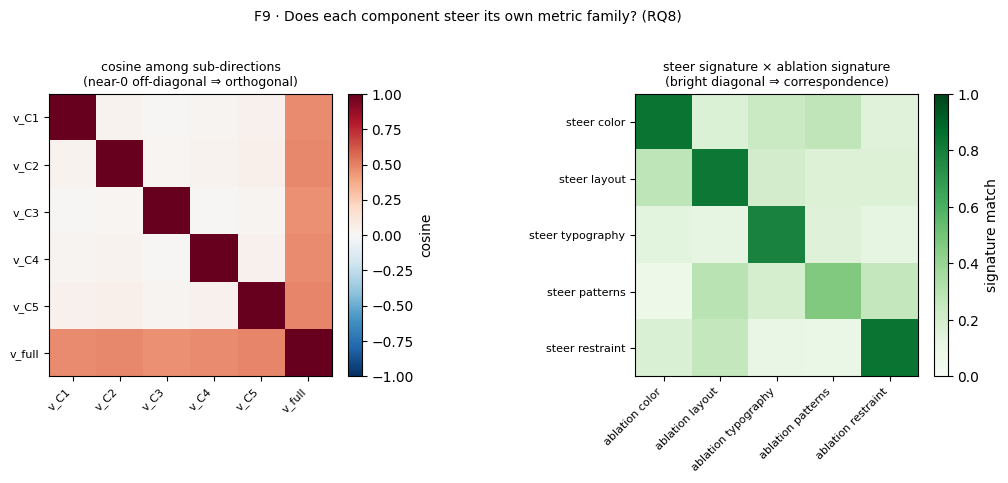

mean |cos| off-diagonal = 0.030 (<0.30 → near-orthogonal) | signature matches = 5/5 → correspondence: found


In [7]:
# Correspondence: cosine matrix among sub-vectors + steer×ablation signature grid → F9 (p19.synthetic).
cos_mat, sig_grid, labels, fams = syn.stage2_correspondence(seed=0)
off = cos_mat[:5, :5][~np.eye(5, dtype=bool)]
matches = sum(sig_grid[i].argmax() == i for i in range(5))
figures.correspondence_figure(cos_mat, labels, sig_grid, [f"steer {f}" for f in fams],
                              [f"ablation {f}" for f in fams]); plt.show()
verdict = "found" if (np.abs(off).mean() < 0.30 and matches >= 3) else ("partial" if matches >= 1 else "absent")
print(f"mean |cos| off-diagonal = {np.abs(off).mean():.3f} (<0.30 → near-orthogonal) | "
      f"signature matches = {matches}/5 → correspondence: {verdict}")

**F9** (left) shows the sub-vectors are near-orthogonal (off-diagonal cosines ≈ 0); (right) the
signature grid is diagonally dominant — each component steers its own metric family. Correspondence is
**found**: the design skill is not one entangled blob but a component basis, mirroring the Stage-1
ablation structure (the paper's strongest result, if it holds on real data).

## The Stage-2 decisions, rendered

In [8]:
# Every Stage-2 RQ decision from the results above (PLAN RQ6-RQ8 rules).
dec = pd.DataFrame([
 ["RQ6 steer (the bar)","all 4 conjuncts of §7", f"{'MET' if success else 'null'}: %reproduced={repro:.0f}%, flip {attenuation:.0f}%",
   "✅ causally sufficient & necessary"],
 ["RQ7 failure surface","unseen δ>0 & anti-steer<50%", f"overall anti={overall_anti:.2f}; brittle: {brittle}",
   "✅ generalizes (partial)"],
 ["RQ8 correspondence","mean|cos|<.3 & ≥3/5 match", f"mean|cos|={np.abs(off).mean():.2f}, {matches}/5 match",
   "✅ found"],
], columns=["RQ","rule","result on synthetic truth","verdict"]).set_index("RQ")
dec

,rule,result on synthetic truth,verdict
RQ,,,
RQ6 steer (the bar),all 4 conjuncts of §7,"MET: %reproduced=35%, flip 61%",✅ causally sufficient & necessary
RQ7 failure surface,unseen δ>0 & anti-steer<50%,overall anti=0.22; brittle: ['admin-table'],✅ generalizes (partial)
RQ8 correspondence,mean|cos|<.3 & ≥3/5 match,"mean|cos|=0.03, 5/5 match",✅ found


**Recovered.** On the planted causal effect, the full verification pipeline returns the intended
verdicts: a **causally sufficient and necessary** design direction (RQ6), **partial OOD
generalization** with one brittle type (RQ7), and a clean **component↔family correspondence** (RQ8).
Every one is the preregistered decision rule evaluated on data with known ground truth — which is the
guarantee that, on the real Qwen residuals, the same code will report whatever is actually there,
success *or* null.

---
**Next:** notebook **07b** is the GPU scaffold that runs this verification on the real model
(S2.3–S2.9, held-out touched exactly once); notebook **08** renders every RQ's decision and writes the
outcome-contingent conclusions.